In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Настройки для красивых графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [3]:
# Создаём папки для сохранения отчёта и графиков
REPORT_DIR = Path('../reports')
FIGURES_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [4]:
# 1. Загрузка данных
DATA_PATH = '../data/raw/nigerian_mobile_money_full.parquet'
print(f"Загрузка данных из {DATA_PATH}...")
df = pd.read_parquet(DATA_PATH)

Загрузка данных из ../data/raw/nigerian_mobile_money_full.parquet...


In [5]:
# Базовые сведения
print("Данные загружены. Размер:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

Данные загружены. Размер: (4000000, 13)

Первые 5 строк:


,transaction_id,wallet_id,timestamp,transaction_type,amount_ngn,fee_ngn,balance_after_ngn,agent_id,channel,device_os,kyc_tier,fraud_flag,churn_30d
0,90e956c0-7e3e-4207-8bbc-90de4c61d05e,WLT-00001530,2024-06-03 20:35:00,airtime,1000.0,10.0,917.204594,,ussd,android,tier2,False,False
1,3cff1814-4796-4e7e-91ff-2cc1240fe8d8,WLT-00001003,2024-04-01 08:34:00,cashin,1150.0,10.0,644.741704,AGT-00004700,ussd,android,tier2,False,False
2,9fb30da5-5e4e-453f-86cc-3cf842d211ac,WLT-00018460,2024-01-08 19:17:00,cashout,4850.0,10.0,3582.585292,AGT-00001615,app,android,tier1,False,False
3,6127f44f-6d23-4d9f-988f-54dcae598f4d,WLT-00000072,2024-04-14 23:10:00,p2p_send,9800.0,98.0,1546.044463,,ussd,android,tier3,False,False
4,f5ca608d-9ddb-40ca-a4ad-39c8474477cd,WLT-00017907,2024-06-14 07:10:00,billpay,1600.0,10.0,4361.698947,,app,feature_phone,tier2,False,False


In [6]:
# 2. Информация о типах данных и пропусках
print("\nИнформация о датафрейме:")
df.info()


Информация о датафрейме:
<class 'pandas.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     str           
 1   wallet_id          str           
 2   timestamp          datetime64[ns]
 3   transaction_type   str           
 4   amount_ngn         float64       
 5   fee_ngn            float64       
 6   balance_after_ngn  float64       
 7   agent_id           str           
 8   channel            str           
 9   device_os          str           
 10  kyc_tier           str           
 11  fraud_flag         bool          
 12  churn_30d          bool          
dtypes: bool(2), datetime64[ns](1), float64(3), str(7)
memory usage: 629.7 MB


In [7]:
# 2. Информация о типах данных и пропусках
print("\nИнформация о датафрейме:")
df.info()

print("\nПропуски по столбцам:")
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "Нет пропусков.")


Информация о датафрейме:
<class 'pandas.DataFrame'>
RangeIndex: 4000000 entries, 0 to 3999999
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   transaction_id     str           
 1   wallet_id          str           
 2   timestamp          datetime64[ns]
 3   transaction_type   str           
 4   amount_ngn         float64       
 5   fee_ngn            float64       
 6   balance_after_ngn  float64       
 7   agent_id           str           
 8   channel            str           
 9   device_os          str           
 10  kyc_tier           str           
 11  fraud_flag         bool          
 12  churn_30d          bool          
dtypes: bool(2), datetime64[ns](1), float64(3), str(7)
memory usage: 629.7 MB

Пропуски по столбцам:
Нет пропусков.


In [8]:
# 3. Распределение классов
class_counts = df['fraud_flag'].value_counts()
class_percents = df['fraud_flag'].value_counts(normalize=True) * 100
print("\nРаспределение классов:")
print(class_counts)
print("\nПроценты:")
print(class_percents)



Распределение классов:
fraud_flag
False    3940000
True       60000
Name: count, dtype: int64

Проценты:
fraud_flag
False    98.5
True      1.5
Name: proportion, dtype: float64


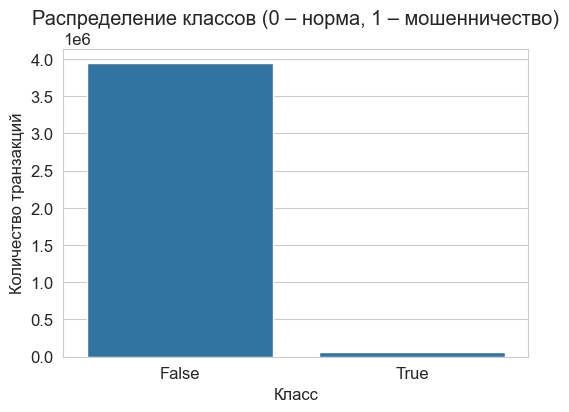

In [9]:
# Сохраним график распределения классов
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_flag', data=df)
plt.title('Распределение классов (0 – норма, 1 – мошенничество)')
plt.xlabel('Класс')
plt.ylabel('Количество транзакций')
plt.show()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

In [ ]:
# 4. Выбросы для amount_ngn и balance_after_ngn (основные числовые признаки)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

In [11]:
print("\nВыбросы (метод IQR):")
for col in ['amount_ngn', 'balance_after_ngn']:
    n_out, low, high = detect_outliers_iqr(df, col)
    print(f"{col}: {n_out} выбросов ({n_out/len(df)*100:.2f}%)")


Выбросы (метод IQR):
amount_ngn: 477971 выбросов (11.95%)
balance_after_ngn: 311041 выбросов (7.78%)


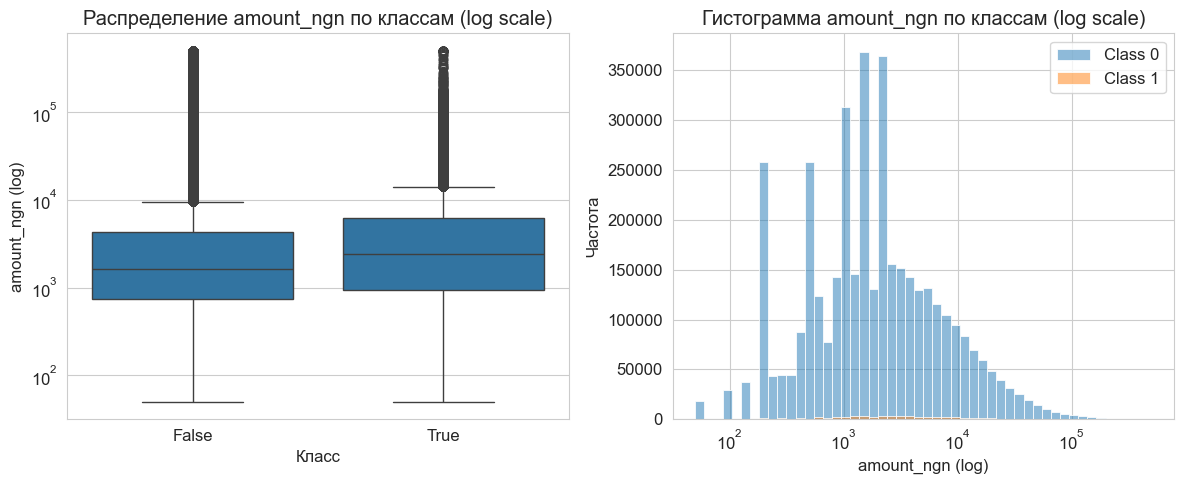

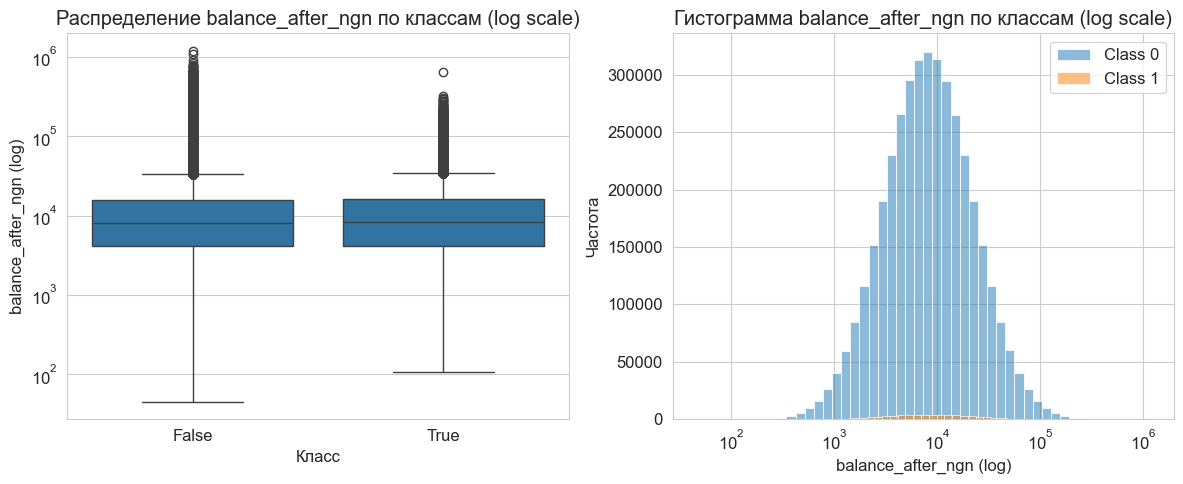

In [16]:
# 5. Визуализация распределения сумм  по классам
for col in ['amount_ngn', 'balance_after_ngn']:

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.boxplot(x='fraud_flag', y=col, data=df)
    plt.yscale('log')  # логарифмическая шкала из-за большого разброса
    plt.title(f'Распределение {col} по классам (log scale)')
    plt.xlabel('Класс')
    plt.ylabel(f'{col} (log)')

    plt.subplot(1,2,2)
    for cls in [0,1]:
        sns.histplot(df[df['fraud_flag']==cls][col], bins=50, label=f'Class {cls}', alpha=0.5, log_scale=True)
    plt.title(f'Гистограмма {col} по классам (log scale)')
    plt.xlabel(f'{col} (log)')
    plt.ylabel('Частота')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{col}_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

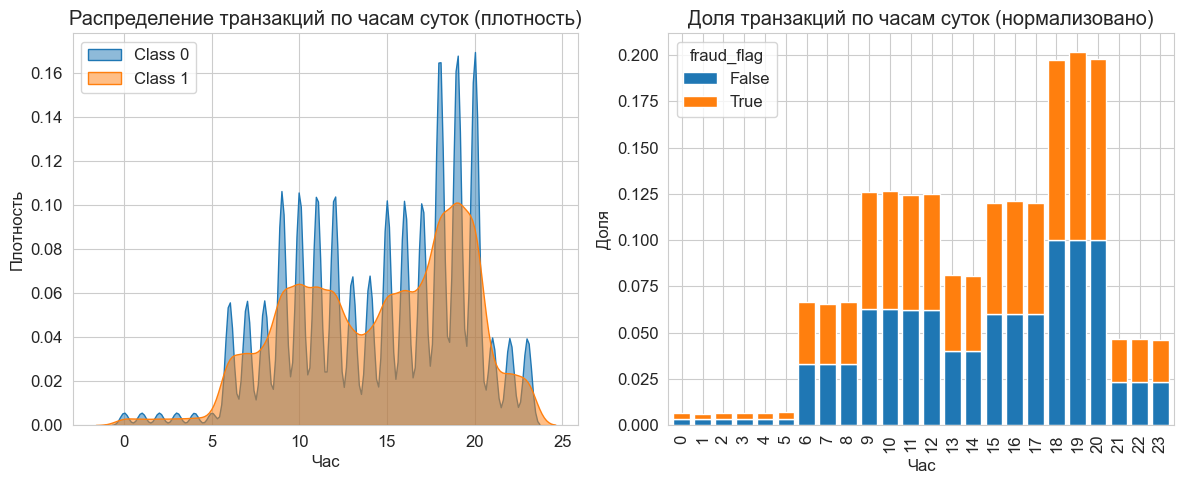

In [37]:
# 7. График распределения транзакций внутри суток для каждого класса
if 'timestamp' in df.columns:
    plt.figure(figsize=(12,5))
    # Вариант 1: гистограмма плотности (kde) по часам для каждого класса
    plt.subplot(1,2,1)
    for cls in [0,1]:
        subset = df[df['fraud_flag'] == cls]
        sns.kdeplot(subset['hour'], label=f'Class {cls}', fill=True, alpha=0.5)
    plt.title('Распределение транзакций по часам суток (плотность)')
    plt.xlabel('Час')
    plt.ylabel('Плотность')
    plt.legend()
    
    # Вариант 2: stacked bar chart с нормализацией внутри классов
    plt.subplot(1,2,2)
    # Группируем по часу и fraud_flag
    hourly_counts = df.groupby(['hour', 'fraud_flag']).size().unstack(fill_value=0)
    # Нормализуем по классам, чтобы сравнить профили
    hourly_norm = hourly_counts.div(hourly_counts.sum(axis=0), axis=1)
    hourly_norm.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.8)
    plt.title('Доля транзакций по часам суток (нормализовано)')
    plt.xlabel('Час')
    plt.ylabel('Доля')
    plt.legend(title='fraud_flag')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'hourly_distribution_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Сохраним данные по часам для отчёта
    hourly_stats = df.groupby('fraud_flag')['hour'].describe()
else:
    print("Столбец 'timestamp' не найден, временные паттерны пропущены.")

In [38]:


# 8. Генерация отчёта в формате Markdown
report_content = f"""# Отчёт по исследовательскому анализу данных (EDA)

## 1. Общая информация
- **Источник данных**: `{DATA_PATH}`
- **Количество строк**: {df.shape[0]}
- **Количество столбцов**: {df.shape[1]}
- **Типы данных**:
{df.dtypes.to_string()}

## 2. Пропуски
{missing.to_string() if missing.any() else "Пропусков не обнаружено."}

## 3. Распределение классов
| Класс | Количество | Процент |
|-------|------------|--------|
| 0 (норма) | {class_counts[False]} | {class_percents[False]:.2f}% |
| 1 (мошенничество) | {class_counts[True]} | {class_percents[True]:.2f}% |

*Ожидалось ~1% мошеннических транзакций, фактически получено {class_percents[True]:.2f}%.*

![Распределение классов](figures/class_distribution.png)

## 4. Выбросы (метод IQR, коэффициент 1.5)
| Признак | Количество выбросов | Процент |
|---------|-------------------|--------|
| amount_ngn  | {detect_outliers_iqr(df, 'amount_ngn')[False]} | {detect_outliers_iqr(df, 'amount_ngn')[False]/len(df)*100:.2f}% |
| balance_after_ngn    | {detect_outliers_iqr(df, 'balance_after_ngn')[False]}   | {detect_outliers_iqr(df, 'balance_after_ngn')[False]/len(df)*100:.2f}% |


*Примечание: выбросы в сумме транзакций могут быть информативны для выявления мошенничества.*

## 5. Распределение суммы транзакций по классам
На графиках ниже видно, что мошеннические транзакции в основном имеют небольшие суммы (логарифмическая шкала).

![Сумма по классам](figures/amount_by_class.png)

## 6. Временные паттерны
Распределение времени транзакций показывает, что мошеннические операции могут быть сконцентрированы в определённых временных интервалах.

![Временные паттерны](figures/time_patterns.png)

Количество транзакций в интервалах времени:

![Количество транзакций по времени](figures/time_binned_counts.png)

## 7. Корреляционная матрица



![Корреляционная матрица для числовых признаков](figures/correlation_matrix_numeric.png)  
![Корреляционная матрица для категориальных признаков](figures/correlation_matrix_categorical.png)


## 8. Заключение
- Данные не содержат пропусков.
- Классы сильно несбалансированы, что требует специальных методов при построении модели.
- Признак и 'amount_ngn', 'balance_after_ngn' имеют выбросы, и они могут быть важны для обнаружения мошенничества.
- Никаких явных пиков мошеннических транзакций в определённые часы не обнаружено.
![Распределение транзаций по часам](figures/hourly_distribution_by_class.png)
- Сильнай взаимной корреляции между признаками не обнаружено

Отчёт создан автоматически.
"""

# Сохраняем отчёт
with open(REPORT_DIR / 'eda_report.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f"\nОтчёт сохранён в {REPORT_DIR / 'eda_report.md'}")
print(f"Графики сохранены в {FIGURES_DIR}")


Отчёт сохранён в ..\reports\eda_report.md
Графики сохранены в ..\reports\figures
